testing repairs generated from MTTF

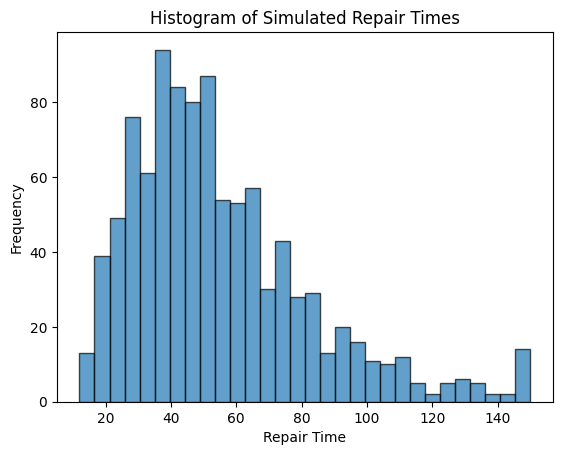

In [1]:
import numpy as np
import matplotlib.pyplot as plt

avg_repair_time =  50  # average repair time
n = 1000

# generate n random repair times based on exponential distribution
repair_times = np.zeros(n)
for i in range(n):
    time_until_repair = np.floor(np.random.lognormal(mean=np.log(avg_repair_time), sigma=0.5))

    # ensure the repair time is at least 1 and at most 3*avg_repair_time
    time_until_repair = max(1, min(time_until_repair, 3 * avg_repair_time))
    repair_times[i] = time_until_repair

# plot histogram of repair times
plt.hist(repair_times, bins=30, edgecolor='black', alpha=0.7)
plt.title('Histogram of Simulated Repair Times')
plt.xlabel('Repair Time')
plt.ylabel('Frequency')
plt.show()


Initializing a Ship from Excel File
![](..\T-AO-system_diagrams.png)

Initialize three ship and simulate them operating and needing repairs with a limitied number of spares onboard. (Perfect Accuracy)

--- Simulation Run 1 ---
Total repairs made: 0
Total unrepairable failures due to lack of spares: 0
Total false failure alarms: 0


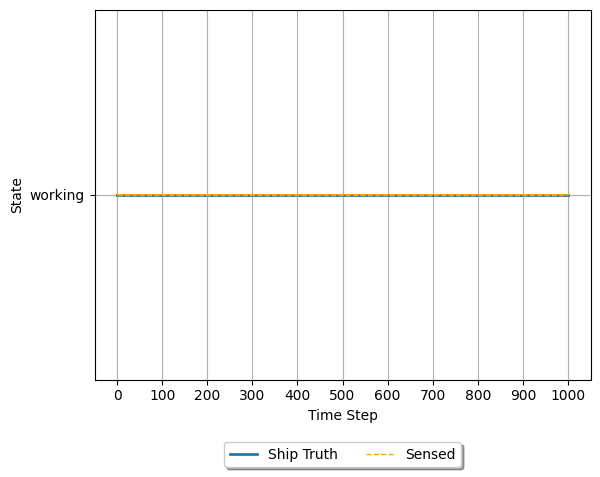

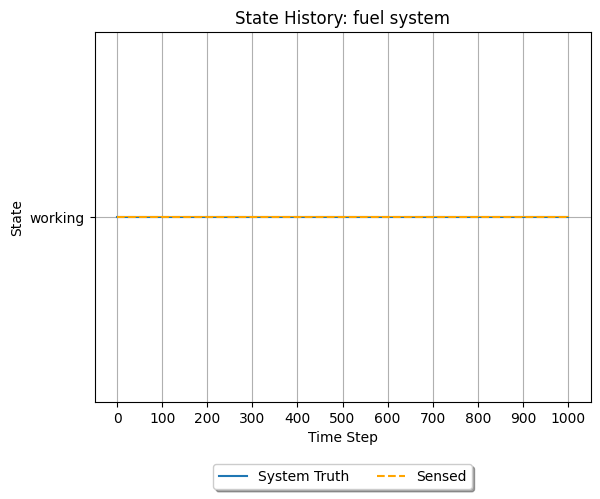

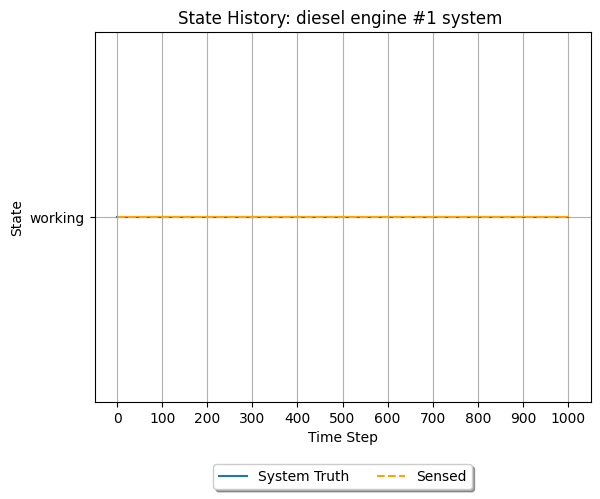

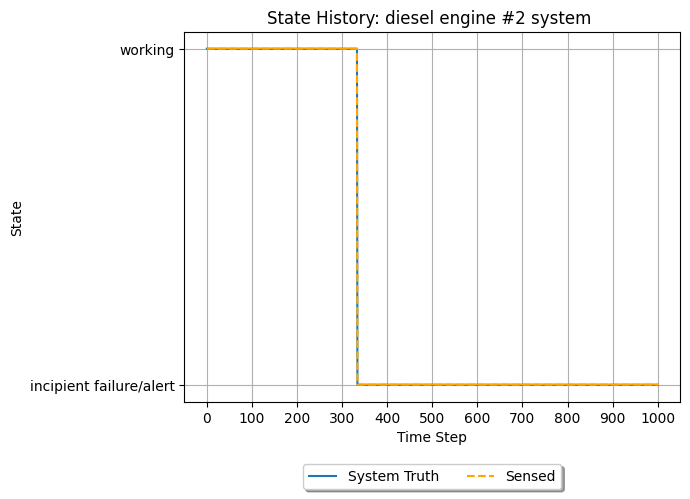

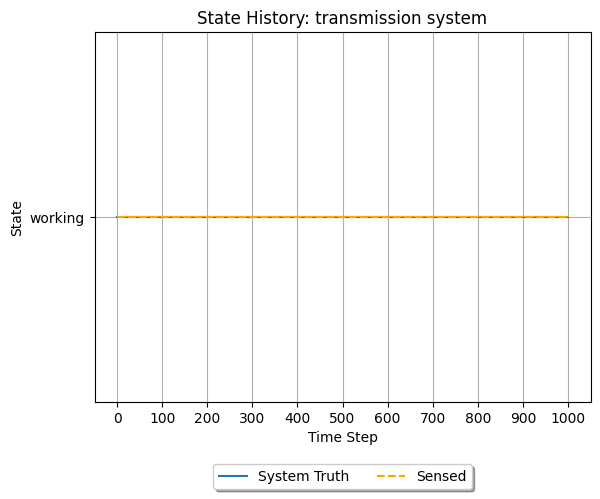




--- Simulation Run 2 ---
Total repairs made: 0
Total unrepairable failures due to lack of spares: 0
Total false failure alarms: 0


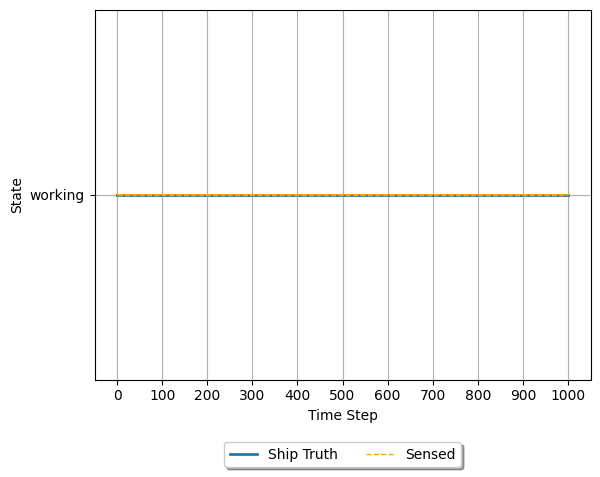

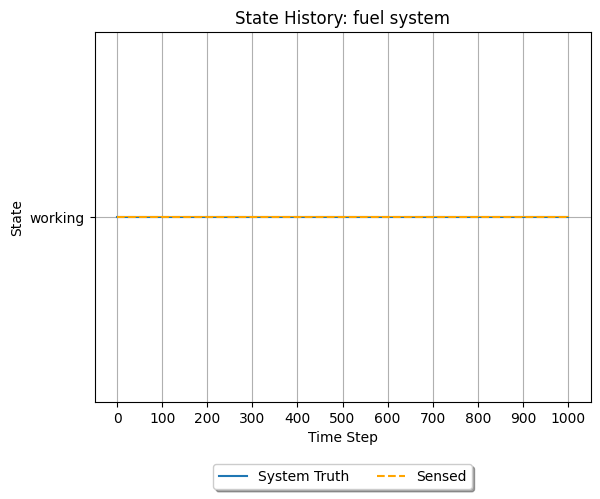

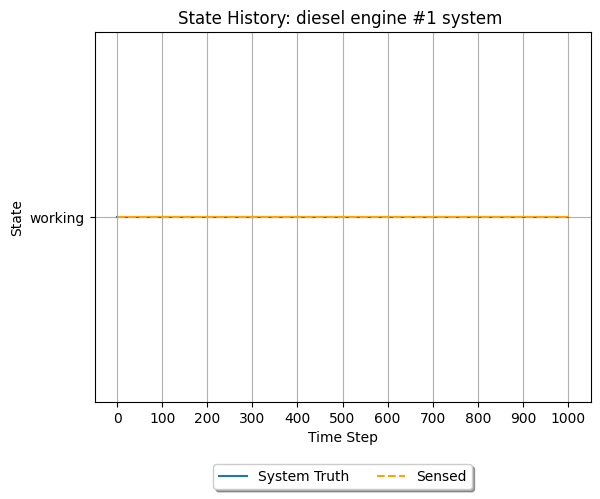

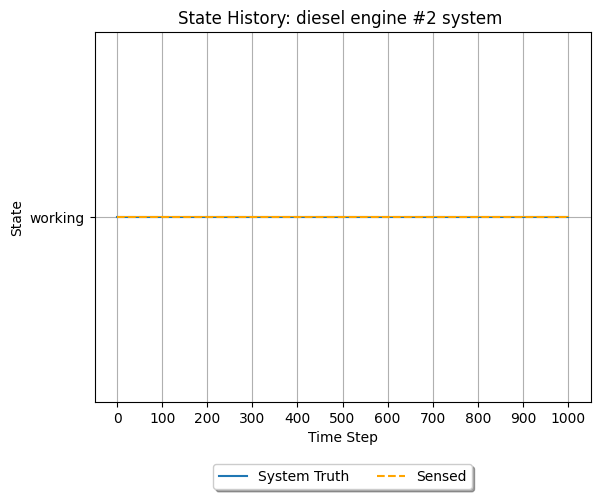

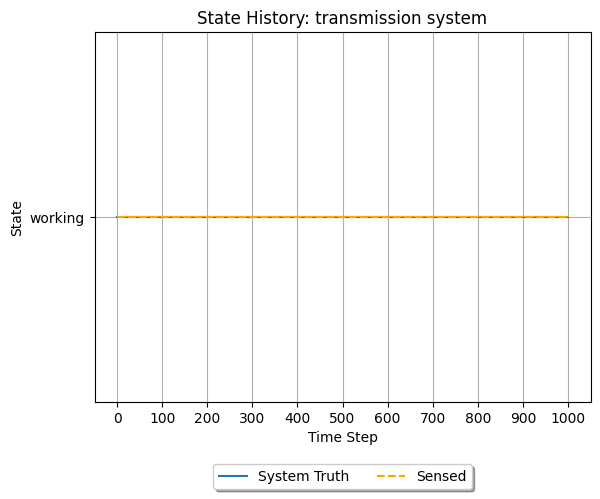




--- Simulation Run 3 ---
Repairing 1 component(s) in system 'diesel engine #2 system '.
Total repairs made: 1
Total unrepairable failures due to lack of spares: 0
Total false failure alarms: 0


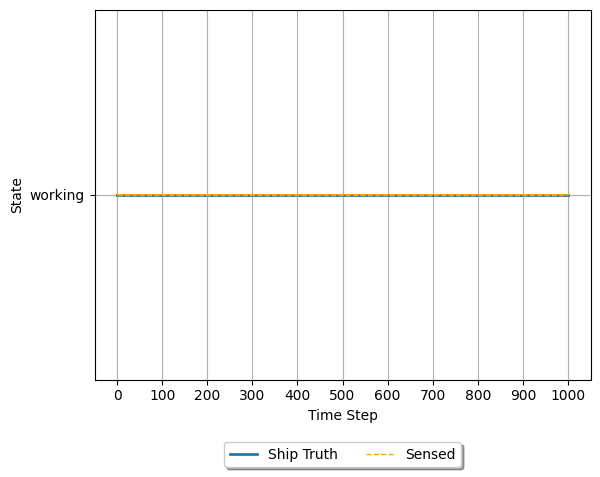

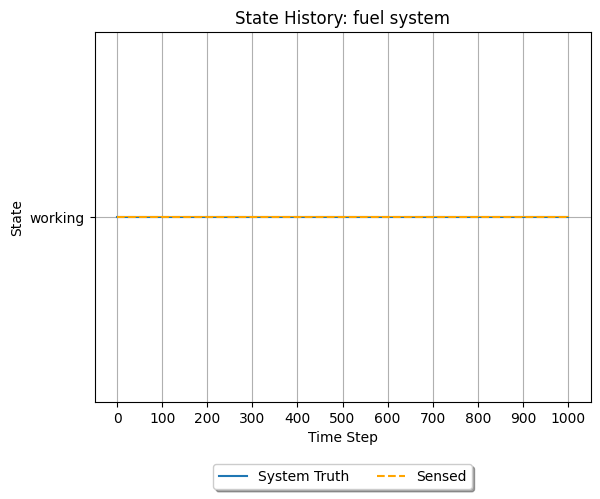

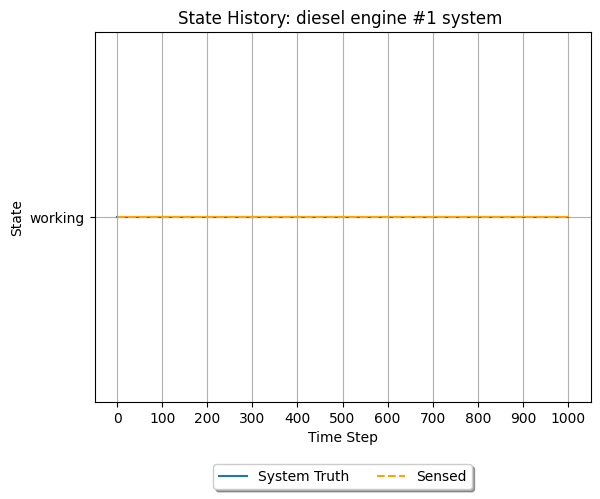

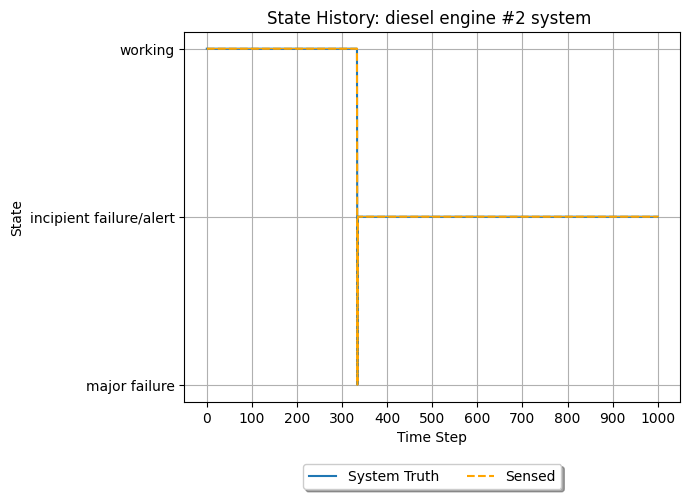

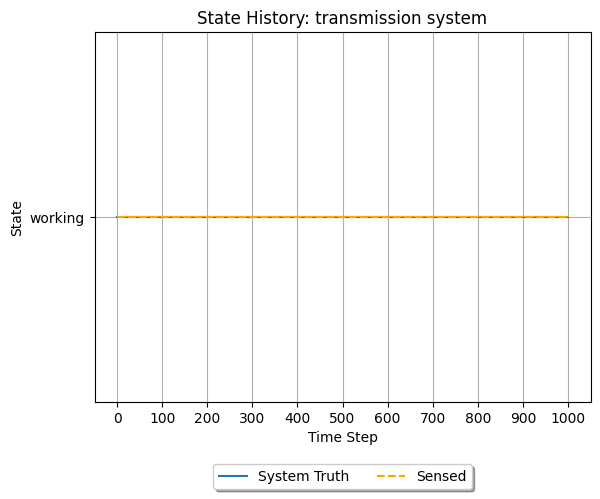

In [13]:
from shipClass.Ship import Ship
from shipClass.SensedShip import SensedShip

from shipClass.SimulateSensedShip import *

for i in range(3): 
    print(f"--- Simulation Run {i+1} ---")

    # initialize a test ship with 100% sensing accuracy
    sensors = (3, 1.00) # (number of sensors, sensing accuracy percentage)
    sensed_aux_ship = initialize_sensed_aux_ship(np_rng_num=i, sensors=sensors)
    # print(f" the ship has a total of {sensed_aux_ship.ship.total_num_comps} components")

    # simulate the ship operating for 720 hours with only 3 spare parts onboard
    simulateWithSpareParts(sensed_aux_ship, time_steps=1000, number_of_spares=3)
    sensed_aux_ship.plotHistory(plot_systems=True)
    
    print("\n\n")


    #*** series comp object has no MTTR (use time_steps = 5000 to trigger error)

Initialize three ship and simulate them operating and needing repairs wiht a limitied number of spares onboard. (Decreased Sensing Accuracy 90%)

--- Simulation Run 1 ---
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'transmission system'. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm fo

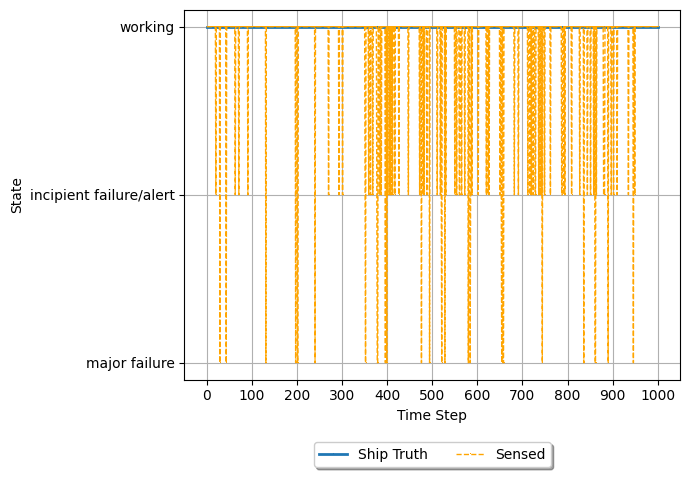

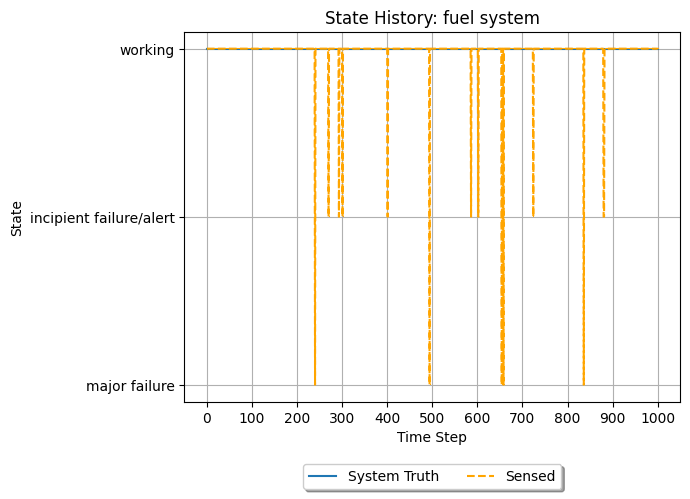

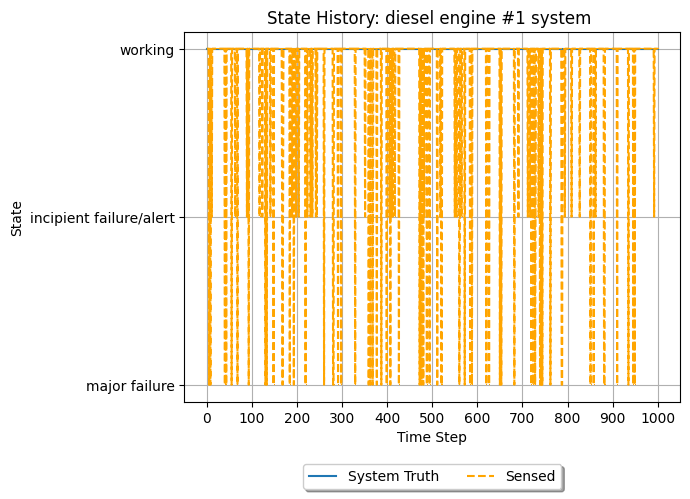

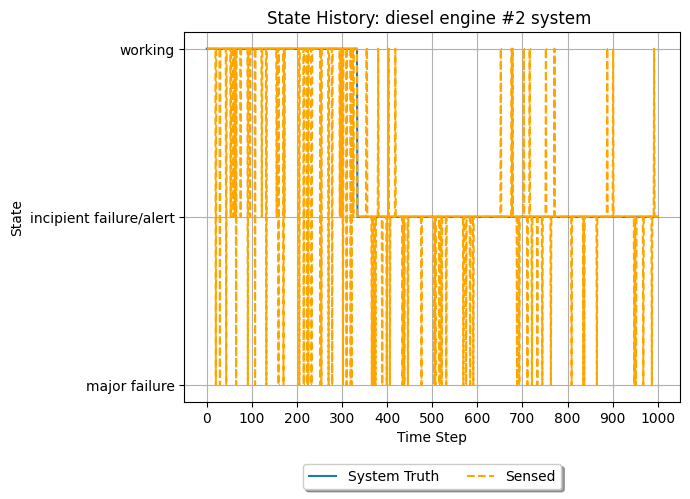

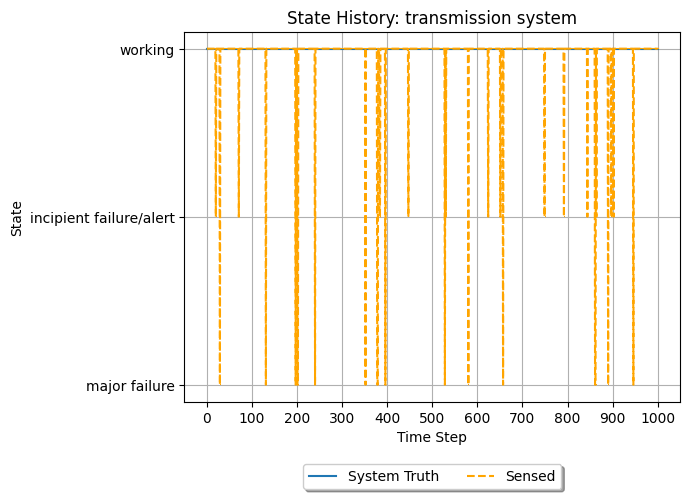




--- Simulation Run 2 ---
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'transmission system'. No repair needed.
False alarm

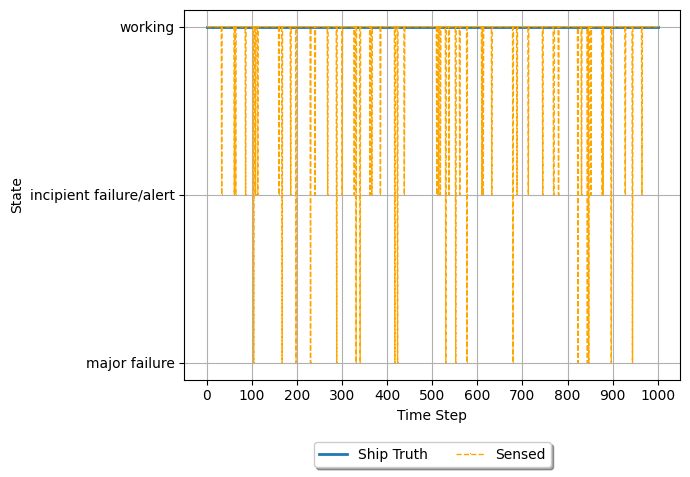

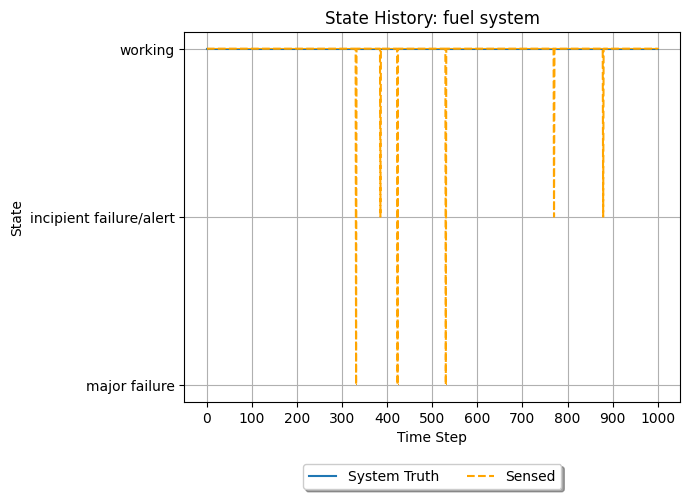

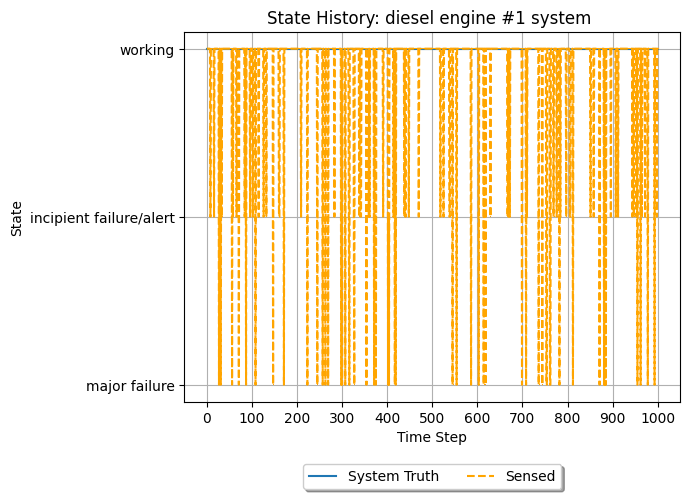

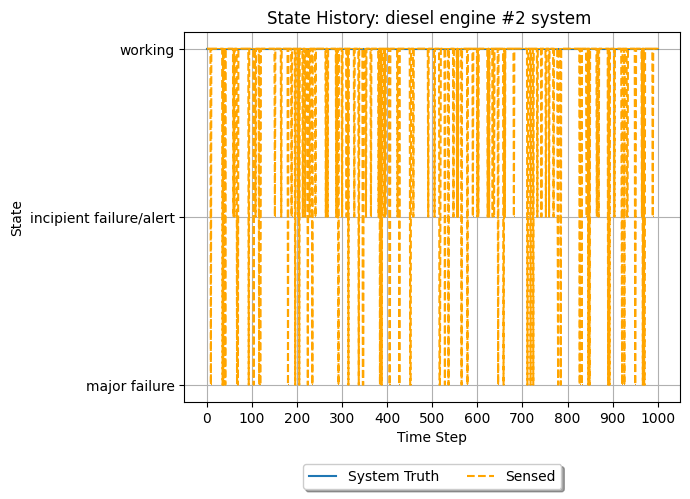

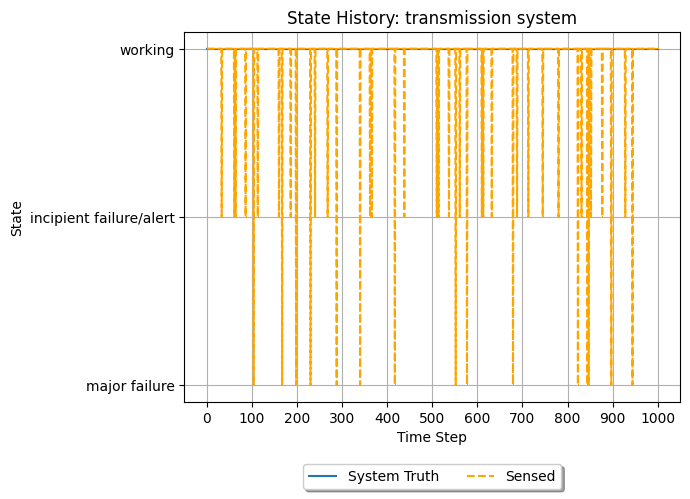




--- Simulation Run 3 ---
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'transmission system'. No repair needed.
False alarm for system 'transmission system'. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'transmission system'. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'diesel engine #2 system '. No repair needed.
False alarm for system 'diesel engine #1 system '. No repair needed.
False alarm for system 'transmission system'. No repair needed.
False alarm for system 'di

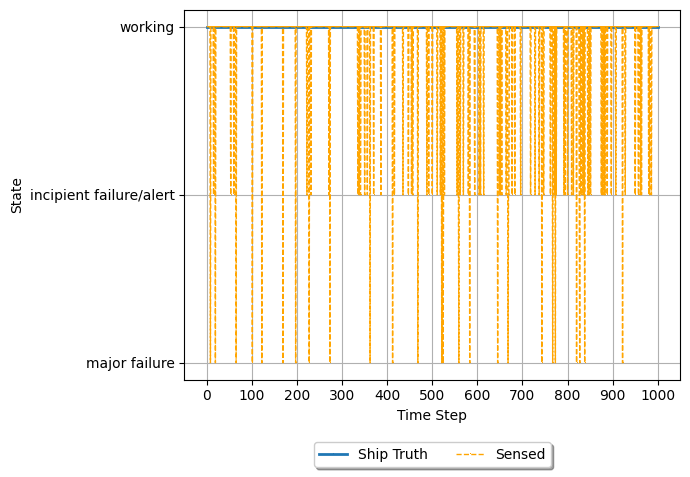

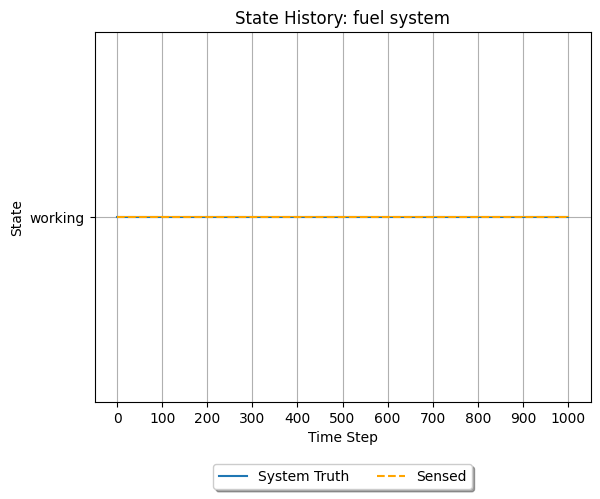

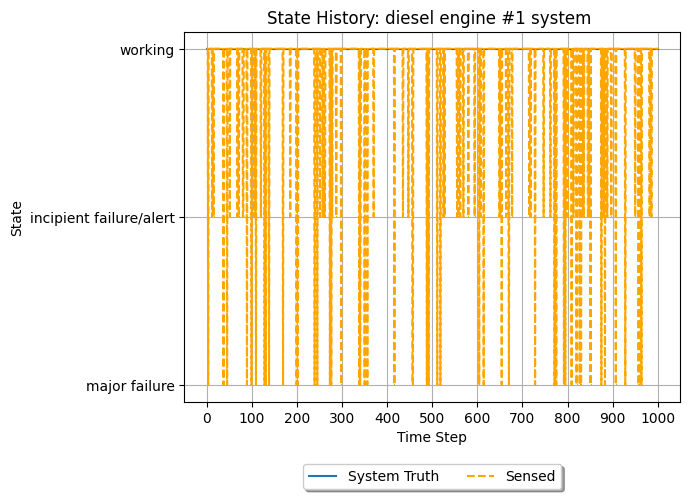

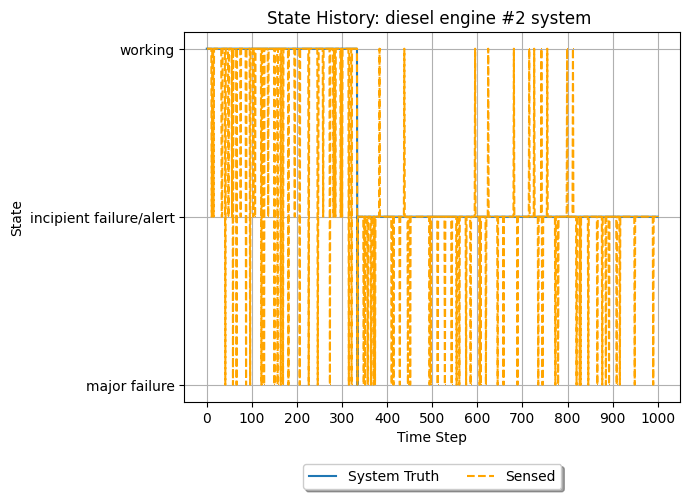

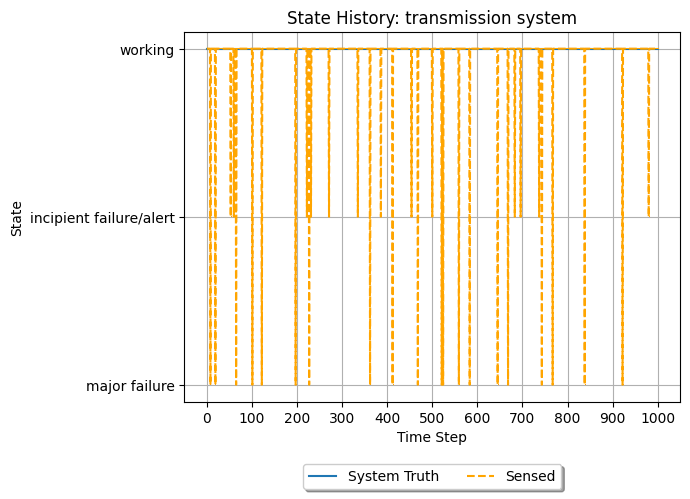

In [9]:
from shipClass.Ship import Ship
from shipClass.SensedShip import SensedShip

from shipClass.SimulateSensedShip import *

for i in range(3): 
    print(f"--- Simulation Run {i+1} ---")

    # initialize a test ship with 80% sensing accuracy
    sensors = (3, 0.90) # (number of sensors, sensing accuracy percentage)
    sensed_aux_ship = initialize_sensed_aux_ship(np_rng_num=i, sensors=sensors)
    # print(f" the ship has a total of {sensed_aux_ship.ship.total_num_comps} components")

    # simulate the ship operating for 720 hours with only 3 spare parts onboard
    simulateWithSpareParts(sensed_aux_ship, time_steps=1000, number_of_spares=3)
    sensed_aux_ship.plotHistory(plot_systems=True)
    
    print("\n\n")


In [10]:
# checking sensors matrices

sensed_aux_ship.sensedSystems[1].sensedComps[0].printSensorMatrix()

Component: Lube Oil Motor
Number of Sensors: 3
Sensor 1 (Quality: 0.9):
[[0.9  0.05 0.05]
 [0.05 0.9  0.05]
 [0.05 0.05 0.9 ]]

Sensor 2 (Quality: 0.9):
[[0.9  0.05 0.05]
 [0.05 0.9  0.05]
 [0.05 0.05 0.9 ]]

Sensor 3 (Quality: 0.9):
[[0.9  0.05 0.05]
 [0.05 0.9  0.05]
 [0.05 0.05 0.9 ]]

